In [1]:
import gpytorch
import math
import torch
from matplotlib import pyplot as plt
import numpy as np

# %matplotlib inline
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from IPython.display import display, Math, Latex

# Scene data

In [2]:
# Load tensors
hr_scene_bed_tensor = torch.load("./torch_data/scene_bed_tensor.pt")
hr_scene_sur_tensor = torch.load("./torch_data/scene_sur_tensor.pt")

In [3]:
print("HR tensor shape:", hr_scene_bed_tensor.unsqueeze(0).shape)

# Magnification factor should if divisor of shape
magnification_factor = 5

# Check remainder
if ((hr_scene_bed_tensor.shape[-1] % magnification_factor) != 0):
    print("ACHTUNG: Magnification his not closed/has remainder. Consider using a different magnification factor.")

magnify = torch.nn.AvgPool2d(kernel_size = magnification_factor)
# stride is by default the kernel size

# Explicit first dim
input = hr_scene_bed_tensor.unsqueeze(0)
lr_scene_bed_tensor = magnify(input)

print("LR tensor shape:", lr_scene_bed_tensor.shape)

HR tensor shape: torch.Size([1, 45, 45])
LR tensor shape: torch.Size([1, 9, 9])


In [4]:
fig = px.imshow(lr_scene_bed_tensor.squeeze(), 
                color_continuous_scale = 'RdBu_r',
                origin = "upper", 
                title = "LR bed scene")
fig.show()

In [5]:
fig = make_subplots(rows = 1, cols = 2,
                    subplot_titles = ("low resolution (lr) bed topography", "high resolution (hr) bed topography"))

fig.add_trace(go.Heatmap(z = lr_scene_bed_tensor.squeeze(), 
                           colorscale = 'RdBu_r'),
                           row = 1, col = 1)

fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor.squeeze(), 
                           colorscale = 'RdBu_r'),
                           row = 1, col = 2)

fig.update_layout(plot_bgcolor = 'rgba(0,0,0,0)')
# matrix style
fig.update_yaxes(autorange = "reversed")
fig.update_traces(showscale = False)
fig.show()


In [6]:
fig = make_subplots(rows = 1, cols = 3,
                    subplot_titles = ("lr bed", "hr bed", "hr surface"))

fig.add_trace(go.Heatmap(z = lr_scene_bed_tensor.squeeze(), 
                           colorscale = 'haline'),
                           row = 1, col = 1)

fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor.squeeze(), 
                           colorscale = 'haline'),
                           row = 1, col = 2)

fig.add_trace(go.Heatmap(z = hr_scene_sur_tensor.squeeze(), 
                           colorscale = 'gray'),
                           row = 1, col = 3)

fig.update_layout(autosize = False, height = 400, width = 900)
fig.update_layout(plot_bgcolor = 'rgba(0,0,0,0)')
# matrix style
fig.update_yaxes(autorange = "reversed")
fig.update_traces(showscale = False)
fig.show()

We will use HR surface to increase the resolution of the bedrock data.

In [7]:
display(Math(r'k\left(A_{H}, A_{H}^{\prime}\right)=\sigma_{f}^{2} k_{S}\left(A_{H}, A_{H}^{\prime}\right) k_{P}\left(P_{H}\left(A_{H}\right), P_{H}\left(A_{H}^{\prime}\right)\right)'))

<IPython.core.display.Math object>

## K_p covariance term

- Pixel intensity covariance function.
- Coupling/decoupling of pixels based on HR context.
- RBF (Squared exponential) kernel without output scale. Distance is calculated only over pixel values:  
 We can flatten the image channel (or channels) as this has no spatial meaning

In [8]:
display(Math(r'k_{P}\left(P_{H}\left(A_{H}\right), P_{H}\left(A_{H}^{\prime}\right)\right)=\exp \left\{-\frac{\left(P_{H}\left(A_{H}\right)-P_{H}\left(A_{H}^{\prime}\right)\right)^{2}}{2 \lambda_{P}^{2}}\right\}'))

<IPython.core.display.Math object>

### Visualise for last row

In [9]:
mask = torch.zeros(size = hr_scene_bed_tensor.squeeze().shape)
mask[-1, :] = torch.ones(size = (hr_scene_bed_tensor.squeeze().shape[0],))

fig = go.Figure(go.Heatmap(z = hr_scene_bed_tensor.squeeze() * mask, colorscale = 'haline'))
fig.update_layout(autosize = False, height = 600, width = 600)
fig.update_yaxes(autorange = "reversed")
fig.show()

In [10]:
# Standardise to get sensitivity of default hp's
def NormalizeTensor(data):
    return (data - torch.min(data)) / (torch.max(data) - torch.min(data))
 
scaled_hr_scene_bed_tensor = NormalizeTensor(hr_scene_bed_tensor)

In [11]:
"""
### GPytorch covariance function###
kp_covar_module = gpytorch.kernels.RBFKernel()
# This kernel does not have an outputscale parameter - just like in paper

lazy_covar_matrix = kp_covar_module(scaled_hr_scene_bed_tensor[44, :]) # Returns a RootLinearOperator
kp_covar_matrix = lazy_covar_matrix.to_dense() # Gets the actual tensor for this kernel matrix
"""

'\n### GPytorch covariance function###\nkp_covar_module = gpytorch.kernels.RBFKernel()\n# This kernel does not have an outputscale parameter - just like in paper\n\nlazy_covar_matrix = kp_covar_module(scaled_hr_scene_bed_tensor[44, :]) # Returns a RootLinearOperator\nkp_covar_matrix = lazy_covar_matrix.to_dense() # Gets the actual tensor for this kernel matrix\n'

In [12]:
# Write my own 1D RBF
def kp_covariance_function(tensor, lambda_p = 0.6):
    """_summary_

    Args:
        tensor (_type_): 2D or 1D tensor but with only one variable
        lambda_p (float, optional): _description_. Defaults to 0.6.

    Returns:
        _type_: rbf covariance 
    """
    # Assuming 1D
    # If tensor is not flat, flatten
    if len(list(tensor.shape)) > 1:
        tensor = tensor.reshape(-1)
    dist = tensor.unsqueeze(-1) - tensor.unsqueeze(-2)
    dist_sqr = torch.pow(dist, exponent = 2)
    dist_sqr_scaled = dist_sqr/torch.pow(torch.tensor(lambda_p), exponent = 2)
    rbf = torch.exp(- dist_sqr_scaled)
    return rbf

In [13]:
# Detach from computational graph
fig = go.Figure(go.Heatmap(z = kp_covariance_function(scaled_hr_scene_bed_tensor[44, :], lambda_p = 0.6), colorscale = 'haline'))
fig.update_layout(autosize = False, height = 600, width = 600, title = "Covaraince matrix for last row of high resolution bed")
fig.update_yaxes(autorange = "reversed")
fig.show()

## K_s covariance term

In [14]:
# arange function exclude the last one: (1, 46) goes up to (not including) 46
xs = torch.arange(1, 46).repeat(45,1)
ys = xs.T

# Divide by 45 to standardise
dims = 45
### Create mid_point data set for spatial kernel ###
mid_points = torch.cat((ys.unsqueeze(0), xs.unsqueeze(0)), dim = 0)/dims

In [15]:
def ks_covariance_function(tensor, lambda_value = 0.2):
    """_summary_

    Args:
        tensor (_type_): _description_
        lambda_s (float, optional): _description_. Defaults to 0.2.

    Returns:
        _type_: _description_
    """
    # If tensor is not flat, flatten
    if len(list(tensor.shape)) > 2:
        # 2 is hardcoded
        tensor = tensor.reshape(2, -1)

    ### Euclidean distance (2D) ###
    # Broadcast and calculate pairwise distances, 
    dist = tensor.unsqueeze(-1) - tensor.unsqueeze(-2)
    dist_sqr = torch.pow(dist, exponent = 2)
    # sum across x and y axis
    dist_sum = torch.sum(dist_sqr, dim = 0)
    # take sqrt
    euc_dist = torch.sqrt(dist_sum)
    
    Z = torch.div(euc_dist, lambda_value)

    # Mask large Z's with nan
    Z[Z >= 1] = float('nan')

    # first term pushes small distanced to 0 and distances near 1 close to zero
    # second terms is clipped at 1 so that smal dists will approach 1
    cov_matrix = torch.pow(1 - Z, exponent = 3) * ((3 * Z) + 1)
    cov_matrix[torch.isnan(cov_matrix)] = 0

    return cov_matrix

In [16]:
# Visualise mapping
Z = torch.tensor(np.linspace(0, 1, 100))
cov_matrix = torch.pow(1. - Z, exponent = 3) * ((3 * Z) + 1)

px.scatter(x = Z.numpy(), y = cov_matrix.numpy(), title = "Mapping of Z").update_layout(
    xaxis_title = "Z value", yaxis_title = "covariance")

### Visualise spatial covariance for one row

In [17]:
# Subset last row
mid_points_last_row = mid_points.reshape(2, -1)[:, -45:]

# Apply function
ks_covar_matrix = ks_covariance_function(mid_points_last_row, lambda_value = 0.2)

In [18]:
fig = go.Figure(go.Heatmap(z = ks_covar_matrix.detach(), colorscale = 'haline'))
fig.update_layout(autosize = False, height = 600, width = 600, title = "Covaraince matrix for last row of HR bed")
fig.update_yaxes(autorange = "reversed")
fig.show()

In [19]:
def ks_kp_covar(lambda_s = 0.3, lambda_p = 0.4, sigma_f = 1.0, rowcol_index_tuple = (44, None), ks_ds = mid_points, kp_ds = scaled_hr_scene_bed_tensor):
    # Subset rows/columns
    (row_index, column_index) = rowcol_index_tuple
    if (column_index == None):
        ks_input = mid_points[:, row_index, :]
        kp_input = kp_ds[row_index, :]
    else:
        ks_input = mid_points[:, :, column_index]
        kp_input = kp_ds[:, column_index]

    ### Ks ### smooth, sparse, local
    # lambda_s is the hp that controls the receptive field
    # ks input
    mid_points
    ks_covar_matrix = ks_covariance_function(ks_input, lambda_value = lambda_s)


    ### Kp ### coupling(decoupling) of similar(dissimilar) pixel values, non-stationary
    # lambda_p is the lengthscale of the RBF kernel
    # default 0.6931
    kp_covar_matrix = kp_covariance_function(kp_input, lambda_p = lambda_p)

    ### VIS ###
    # sigma_f is the output variance of the product term
    # Fix cmin and cmax to see sensitivity to output scalar
    fig = make_subplots(rows = 1, cols = 3,
                    subplot_titles = ("Ks", "Kp", "Ks * Kp * sigma_f"))

    fig.add_trace(go.Heatmap(z = ks_covar_matrix.detach().numpy(), 
                         zmin = 0, zmax = 1, 
                         colorscale = [[0, "rgb(242, 243, 34)"],
                                       [0.25, "rgb(251, 168, 54)"],
                                       [0.45, "rgb(240, 130, 77)"],
                                       [0.65, "rgb(202, 69, 122)"],
                                       [0.85, "rgb(136, 22, 163)"],
                                       [1, "rgb(43, 22, 146)"]]),
                         row = 1, col = 1)

    fig.add_trace(go.Heatmap(z = kp_covar_matrix.detach().numpy(), 
                         zmin = 0, zmax = 1, 
                         colorscale = [[0, "rgb(242, 243, 34)"],
                                       [0.25, "rgb(251, 168, 54)"],
                                       [0.45, "rgb(240, 130, 77)"],
                                       [0.65, "rgb(202, 69, 122)"],
                                       [0.85, "rgb(136, 22, 163)"],
                                       [1, "rgb(43, 22, 146)"]]),
                         # colorscale = 'haline'),
                         row = 1, col = 2)
    
    fig.add_trace(go.Heatmap(z = ks_covar_matrix.detach().numpy() * kp_covar_matrix.detach().numpy() * sigma_f,
                             # Trade off paramater (ks_covar_matrix.detach().numpy() * (1 - sigma_f)) * (kp_covar_matrix.detach().numpy() * sigma_f)
                         zmin = 0, zmax = 1, 
                         colorscale = [[0, "rgb(242, 243, 34)"],
                                       [0.25, "rgb(251, 168, 54)"],
                                       [0.45, "rgb(240, 130, 77)"],
                                       [0.65, "rgb(202, 69, 122)"],
                                       [0.85, "rgb(136, 22, 163)"],
                                       [1, "rgb(43, 22, 146)"]]),
                           row = 1, col = 3)

    fig.update_layout(autosize = False, height = 400, width = 900)
    fig.update_yaxes(autorange = "reversed") # matrix style
    fig.update_traces(showscale = False)
    fig.show()

In [20]:
ks_kp_covar(lambda_s = 0.5, lambda_p = 0.08, sigma_f = 0.8, rowcol_index_tuple = (None, 44), ks_ds = mid_points, kp_ds = scaled_hr_scene_bed_tensor)
# Good example:
# ks_kp_covar(lambda_s = 0.6, lambda_p = 0.08, sigma_f = 0.8, rowcol_index_tuple = (None, 44), ks_ds = mid_points, kp_ds = scaled_hr_scene_bed_tensor)
# higher lambda_s improves receptive spatial region. Cut-off point for zero covariance.
# lower lambda_p makes it more sensitive to filter out high pixel correlation values
# output scaling
# ks_kp_covar(lambda_s = 0.99, lambda_p = 0.8, sigma_f = 0.5, rowcol_index_tuple = (1, None), ks_ds = mid_points, kp_ds = scaled_hr_scene_bed_tensor)

In [21]:
def covariance_function(kp_ds, lambda_s = 0.3, lambda_p = 0.4, sigma_f = 1.0):

    # Assuming square shape
    dims = kp_ds.shape[1]
    # create input for ks kernel
    mid_points = torch.cat((ys.unsqueeze(0), xs.unsqueeze(0)), dim = 0)/dims

    ### Ks ### smooth, sparse, local
    # lambda_s is the hp that controls the receptive field
    ks_input = mid_points[:, :, :]
    ks_covar_matrix = ks_covariance_function(tensor = ks_input, lambda_value = lambda_s)


    ### Kp ### coupling(decoupling) of similar(dissimilar) pixel values, non-stationary
    # lambda_p is the lengthscale of the RBF kernel
    # default 0.6931
    kp_input = kp_ds[:, :]
    kp_covar_matrix = kp_covariance_function(kp_input, lambda_p = lambda_p)
    
    return (ks_covar_matrix.detach().numpy() * kp_covar_matrix.detach().numpy() * sigma_f)
                        

This is more interesting if we look at covariance not with the same vector:

Use one row and one column vector.

## Low res

In [22]:
lr_scene_bed_tensor_norm = NormalizeTensor(lr_scene_bed_tensor)
hr_scene_sur_tensor_norm = NormalizeTensor(hr_scene_sur_tensor)

# Only for visualisation: not used
hr_scene_bed_tensor_norm = NormalizeTensor(hr_scene_bed_tensor)

print(lr_scene_bed_tensor_norm.shape)
print(hr_scene_sur_tensor_norm.shape)
# 9 * 9 * 25
# NH is the number of high-resolution AH areas that compose AL: 25 HR areas compose one LR area (5 x 5)

torch.Size([1, 9, 9])
torch.Size([45, 45])


In [23]:
fig = make_subplots(rows = 1, cols = 3,
                    subplot_titles = ("lr bed", "hr bed", "hr surface"))

fig.add_trace(go.Heatmap(z = lr_scene_bed_tensor.squeeze()[:5, :5], 
                           colorscale = 'haline'),
                           row = 1, col = 1)

fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor.squeeze()[:25, :25], 
                           colorscale = 'haline'),
                           row = 1, col = 2)

fig.add_trace(go.Heatmap(z = hr_scene_sur_tensor.squeeze()[:25, :25], 
                           colorscale = 'gray'),
                           row = 1, col = 3)

fig.update_layout(autosize = False, height = 400, width = 900)
fig.update_layout(plot_bgcolor = 'rgba(0,0,0,0)')
# matrix style
fig.update_yaxes(autorange = "reversed")
fig.update_traces(showscale = False)
fig.show()

In [24]:
fig = make_subplots(rows = 1, cols = 3,
                    subplot_titles = ("Input: low-res bed", "Input: hih-res surface", "Target: high-res bed"))

fig.add_trace(go.Heatmap(z = lr_scene_bed_tensor.squeeze()[:5, :5], 
                           colorscale = 'haline'),
                           row = 1, col = 1)

fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor.squeeze()[:25, :25], 
                           colorscale = 'haline'),
                           row = 1, col = 3)

fig.add_trace(go.Heatmap(z = hr_scene_sur_tensor.squeeze()[:25, :25], 
                           colorscale = 'gray'),
                           row = 1, col = 2)

fig.update_layout(autosize = False, height = 400, width = 900)
fig.update_layout(plot_bgcolor = 'rgba(0,0,0,0)')
# matrix style
fig.update_yaxes(autorange = "reversed")
fig.update_traces(showscale = False)
fig.show()

### Base covariance

(array([ 84., 325., 215., 231., 185., 293., 257., 277., 131.,  27.]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <BarContainer object of 10 artists>)

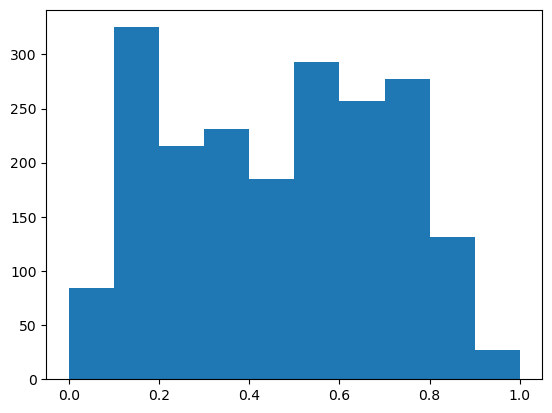

In [37]:
# Dist is not Gaussian
# plt.hist(hr_scene_sur_tensor_norm.reshape(-1))

In [39]:
### Base Covariance ###
# base covariance is based on high-res input only
base_covar = covariance_function(hr_scene_sur_tensor_norm, lambda_s = 0.4, lambda_p = 0.3, sigma_f = 1.0) # torch.Size([2025, 2025])
# lambda_s = 0.1 produces stripes (too local, small lengthscale)
# lambda_p = 0.05 produces swirls
# sigma_f = 0.01 keeps it closer to the mean field: Keep at 1.0 to stay in [0, 1] range

# Functions to average over base covariance to derive k_ah_al and k_al_al terms
# Magnification factor for this problem
magnification_factor = 25
# Use average pooling function
magnify_5x5blocks = torch.nn.AvgPool2d(kernel_size = magnification_factor)
magnify_25columns = torch.nn.AvgPool2d(kernel_size = (1, magnification_factor), stride = (1, magnification_factor))

(array([[1897.,   34.,   19., ...,    7.,    7.,    8.],
        [1882.,   40.,   22., ...,    8.,    8.,   11.],
        [1866.,   45.,   23., ...,    9.,   10.,   13.],
        ...,
        [1894.,   34.,   22., ...,    8.,    8.,   12.],
        [1903.,   32.,   23., ...,    7.,    6.,   11.],
        [1915.,   31.,   19., ...,    4.,    6.,    7.]]),
 array([0.        , 0.1       , 0.2       , 0.30000001, 0.40000001,
        0.5       , 0.60000002, 0.69999999, 0.80000001, 0.89999998,
        1.        ]),
 <a list of 2025 BarContainer objects>)

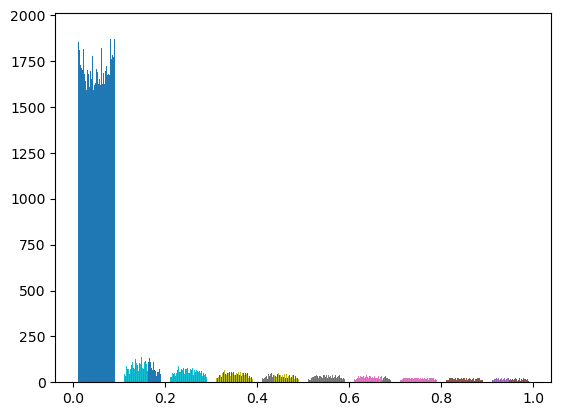

In [41]:
# sparse: many zeros
plt.hist(base_covar)

(array([[68.,  4.,  3., ...,  0.,  0.,  0.],
        [68.,  4.,  3., ...,  0.,  0.,  0.],
        [68.,  2.,  4., ...,  0.,  0.,  0.],
        ...,
        [68.,  4.,  3., ...,  0.,  0.,  0.],
        [69.,  4.,  2., ...,  0.,  0.,  0.],
        [70.,  5.,  1., ...,  0.,  0.,  0.]]),
 array([0.        , 0.01117906, 0.02235812, 0.03353719, 0.04471625,
        0.05589531, 0.06707437, 0.07825343, 0.08943249, 0.10061156,
        0.11179062]),
 <a list of 2025 BarContainer objects>)

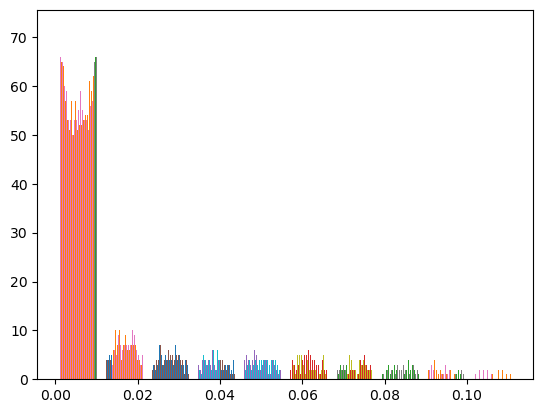

In [42]:
plt.hist(k_ah_al)

(array([[62.,  6.,  4.,  2.,  2.,  3.,  0.,  1.,  0.,  1.],
        [61.,  4.,  7.,  1.,  3.,  1.,  3.,  0.,  1.,  0.],
        [60.,  3.,  5.,  3.,  3.,  2.,  2.,  2.,  1.,  0.],
        [59.,  3.,  6.,  4.,  3.,  3.,  2.,  1.,  0.,  0.],
        [58.,  4.,  5.,  3.,  2.,  3.,  3.,  1.,  2.,  0.],
        [58.,  4.,  6.,  3.,  4.,  3.,  2.,  1.,  0.,  0.],
        [56.,  4.,  6.,  3.,  2.,  2.,  5.,  0.,  2.,  1.],
        [55.,  6.,  6.,  3.,  3.,  5.,  2.,  1.,  0.,  0.],
        [54.,  6.,  6.,  2.,  3.,  2.,  4.,  1.,  2.,  1.],
        [53.,  7.,  5.,  4.,  2.,  6.,  2.,  1.,  1.,  0.],
        [52.,  6.,  7.,  2.,  5.,  3.,  3.,  1.,  2.,  0.],
        [51.,  4.,  7.,  4.,  4.,  5.,  3.,  2.,  1.,  0.],
        [51.,  4.,  7.,  4.,  6.,  6.,  1.,  2.,  0.,  0.],
        [49.,  3., 10.,  3.,  5.,  3.,  5.,  1.,  1.,  1.],
        [48.,  7.,  8.,  6.,  4.,  5.,  2.,  1.,  0.,  0.],
        [47.,  7.,  8.,  3.,  4.,  2.,  6.,  1.,  2.,  1.],
        [46.,  8.,  9.,  5.,  4.,  6.,  

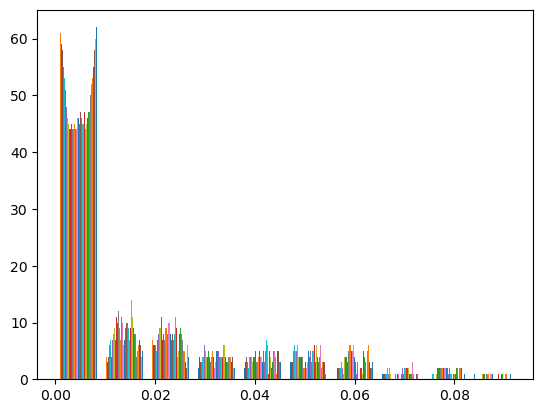

In [43]:
plt.hist(k_al_al)

In [31]:
# fix hypers for now
mu = 0.5
noise = 0.01

# Last term: Subtract mean from low-res pixel values. Tensor thus ranges from -0.5 to 0.5
pl_al_minus_mu = lr_scene_bed_tensor_norm - torch.ones(size = lr_scene_bed_tensor_norm.shape) * mu # torch.Size([1, 9, 9])

k_ah_al = magnify_25columns(torch.tensor(base_covar).unsqueeze(0)).squeeze() # torch.Size([2025, 81])
k_al_al = magnify_5x5blocks(torch.tensor(base_covar).unsqueeze(0)).squeeze() # torch.Size([81, 81])
# smaller domain: both k_ah_al and k_al_al only occupy 0, 0.1

# Multiply three terms
hr_bed_inf = torch.matmul(k_ah_al,
    torch.matmul(torch.linalg.inv(k_al_al + (torch.eye(n = k_al_al.shape[-1]) * noise)), 
             pl_al_minus_mu.squeeze().reshape(-1))) + mu

# Unadjusted
hr_bed_inf_unadjusted = torch.matmul(k_ah_al,
    torch.matmul(torch.linalg.inv(k_al_al + (torch.eye(n = k_al_al.shape[-1]) * noise)), 
             pl_al_minus_mu.squeeze().reshape(-1))) + mu

# Adjusted
# Reweighting:
W = torch.matmul(k_ah_al, torch.linalg.inv(k_al_al + (torch.eye(n = k_al_al.shape[-1]) * noise))) # torch.Size([2025, 81])
# Neg values

# numerator is torch.Size([2025])
# denominator is torch.Size([2025])
hr_bed_inf_adjusted = torch.div(torch.matmul(W, pl_al_minus_mu.reshape(-1).unsqueeze(1)), torch.matmul(W, torch.ones(size = (81, 1)))) + mu

# Cast into 2D shape
hr_bed_inf_2D = hr_bed_inf_adjusted.reshape(45, -1)

## Normaise/ Reweighting
# Input warping?

In [34]:
fig = make_subplots(rows = 1, cols = 4,
                    subplot_titles = ("low-res bed", "high-res surface", "high-res bed INFERRED", "high-res bed GROUND TRUTH"))

fig.add_trace(go.Heatmap(z = lr_scene_bed_tensor_norm.squeeze(), 
                           colorscale = 'haline', zmin = 0, zmax = 1),
                           row = 1, col = 1)

fig.add_trace(go.Heatmap(z = hr_scene_sur_tensor_norm.squeeze(), 
                           colorscale = 'haline', zmin = 0, zmax = 1),
                           row = 1, col = 2)

fig.add_trace(go.Heatmap(z = NormalizeTensor(hr_bed_inf_2D), 
                           colorscale = 'haline', zmin = 0, zmax = 1),
                           row = 1, col = 3)

# fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor_norm.squeeze(), 
#                           colorscale = 'haline', zmin = 0, zmax = 1),
#                           row = 1, col = 4)

# Use difference instead
fig.add_trace(go.Heatmap(z = hr_scene_bed_tensor_norm.squeeze() - hr_bed_inf_2D, 
                           colorscale = 'haline', zmin = 0, zmax = 1),
                           row = 1, col = 4)

fig.update_layout(autosize = False, height = 400, width = 1200)
fig.update_layout(plot_bgcolor = 'rgba(0,0,0,0)')
# matrix style
fig.update_yaxes(autorange = "reversed")
fig.update_traces(showscale = False)
fig.show()

## To Do's

- Implement reweighting/pixel correction using low-res data
- LML to infer the best parameters
- Create new covariance function
- Clip image values to between 0 and 1.
- Why do we have so many values outside
- look at distributions of variables like base covar

## Metrics

1. Mean squared error
2. Universal Image Quality index (Wang, Zhou, and Alan C. Bovik. "A universal image quality index." IEEE signal processing letters 9.3 (2002): 81-84.)
   Is this applicable to images which are not rbg?
   - loss of correlation
   - luminance distortion
   - contrast distortion

Look at DeepBedMap paper.

In [46]:
def mse(image1, image2):
    # Take in two tensors of the same size and check t

    # Check
    if (image1.shape != image2.shape):
        print("Input images are not the same size. MSE can't be calculated")

    squared_error_tensor = torch.pow(torch.div(image1.detach(), image2.detach()), exponent = 2)
    mean_squared_error = torch.mean(squared_error_tensor)

    return(mean_squared_error)

In [47]:
# Domain is off.. check code
print(torch.max(hr_bed_inf_2D))
print(torch.min(hr_bed_inf_2D))

tensor(1.9472)
tensor(-1.4983)
